# M6 — Optimizers as associative memories

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bdsaglam/bdsaglam.github.io/blob/main/courses/continual-learning/foundations/m6-optimizers-as-memory.ipynb)

**The question:** why are momentum, Adam, and Muon *also* memories?

The delta rule fixed the additive write inside the sequence memory: read what the memory already returns for this key, then write only the correction. Meta-learning followed that write *inward*, asking who supplies its arguments and what happens when the memory supplies its own. Now turn back to the write itself — because the fix has a second home. There is another additive write in every model you have ever trained: the **optimizer**, piling gradients onto a memory of the gradient stream. The same error-correcting fix applies one level up.

> **Prerequisite math** — *condition number* (the zig-zag), *orthogonality* (orthogonal tasks), and *effective rank* are collected in the [linear-algebra primer](../primers/linear-algebra.ipynb).

## Objective

After this module you should be able to:

- Show that one backprop step on a layer is an **associative-memory write**: $\partial\mathcal L/\partial W=\boldsymbol\delta\,\hat{\mathbf x}^\top$, an outer product with **key = layer input**, **value = output surprise**.
- Explain why this memory is **self-referential**: it generates its own write targets, so it is *not* just linear attention on gradients.
- Read **momentum** as a second memory, one level down: an associative memory that compresses the **gradient stream**, and see why the plain EMA is only a low-pass filter with a hard capacity limit.
- Apply the **same delta-rule fix** one level up: **DGD** (delta rule on the weights) and **Delta Momentum** (delta rule on the buffer), and see them behave like DeltaNet did against linear attention in M4.
- Place Adam / Muon in the same picture (preconditioning = a learned coordinate map; Muon = a non-linearity on the momentum memory).

## Why it exists (the limitation it fixes)

M4 diagnosed the additive write and cured it. Linear attention's memory only ever *added*: $\mathcal{M}_t=\mathcal{M}_{t-1}+\mathbf{v}_t\mathbf{k}_t^\top$. It could not edit an association, only pile onto it. The delta rule inserted a **read** before the write: look at what the memory already returns for this key, and write only the correction.

That fix has a second home, and you have been running the broken version of it for as long as you have trained models.

Every optimizer is an additive write nobody thinks of as one. Plain SGD adds the momentary gradient to the weights and consults nothing about what is already stored there. Momentum keeps a running memory of the **gradient stream**, $\mathbf{m}_{t+1}=\alpha\mathbf{m}_t-\eta\nabla\mathcal{L}$, and *piles* each new gradient onto it: the buffer is scaled by $\alpha$, but the thing being written in is the raw gradient, chosen without ever reading the buffer. That is exactly the state-blind Hebbian write, the one the delta rule repaired — just one level up, over a different stream. NL diagnoses it the same way: momentum's update rule is *"independent of its current state"*, and so has *"limited capacity"* (§4.4).

So the module asks two questions, in order. What does the memory look like from up there — what are the keys and the values when the thing doing the storing is the optimizer? And what does M4's fix become when you apply it there?

## The core idea in one line

$$\boxed{\ \underbrace{W_{t+1}=W_t-\eta\,\nabla_W\mathcal L}_{\text{one SGD step}}\ \equiv\ \underbrace{W_{t+1}=W_t+\eta\,\mathbf u_t\,\hat{\mathbf x}_t^\top}_{\text{one Hebbian write}}\ }\qquad \mathbf u_t=-\boldsymbol\delta_t=-\frac{\partial\mathcal L}{\partial\mathbf y_t}$$

A gradient step writes the association **"layer input $\hat{\mathbf x}_t$ → output-surprise $\mathbf u_t$"** into $W$. Training is the memory *filling up*. Everything else in this module is: *which* write rule (Hebbian / delta / preconditioned), over *which* stream (raw gradients, momentum buffer), with *how much* structure (a matrix, an MLP).

### Reading

- [Nested Learning](https://arxiv.org/abs/2512.24695) (Behrouz, Razaviyayn, Zhong & Mirrokni, 2025) — the grounding source for the whole module. §4.1 (Eqs. 29–31, backprop as an associative memory; the *Backpropagation $\neq$ Linear Attention* note), §4.2 (Eqs. 32–37, momentum as a memory; Eqs. 38–42, preconditioning and Muon), §4.3 (the low-pass capacity limit and the orthogonal-tasks failure), §4.4 (Eqs. 48–52, Delta Momentum, DMGD and non-linear outputs; Eq. 53, the time-varying-curvature toy), §4.5 (Eqs. 54–58, DGD and the self-referential reading).

## 1. Backprop is an associative-memory write

For a layer $\mathbf y=W\hat{\mathbf x}$, the gradient w.r.t. the **matrix** $W$ factors into an outer product (NL Eq. 29):

$$\frac{\partial\mathcal L}{\partial W}=\boldsymbol\delta\,\hat{\mathbf x}^\top,\qquad \boldsymbol\delta=\frac{\partial\mathcal L}{\partial\mathbf y}\ \ (\text{local output surprise}),$$

because $\partial\mathcal L/\partial W_{ij}=(\partial\mathcal L/\partial y_i)\,\hat x_j$ — *"how wrong output $i$ was"* times *"input $j$."* So one SGD step $W\!\leftarrow\!W-\eta\,\boldsymbol\delta\hat{\mathbf x}^\top$ is exactly the Hebbian write $\mathcal M\mathrel{+}=\mathbf v\mathbf k^\top$ from **M1**, with **key $=\hat{\mathbf x}$** (input) and **value $=-\boldsymbol\delta$** (negative surprise).

In [ ]:
import numpy as np
import torch

torch.manual_seed(0)

# a single linear layer y = W x, with a squared-error task loss
W = torch.randn(3, 5, requires_grad=True)
x = torch.randn(5)
target = torch.randn(3)

y = W @ x
loss = 0.5 * ((y - target) ** 2).sum()
loss.backward()

delta = (y - target).detach()  # δ = ∂L/∂y  (output surprise)
outer = torch.outer(delta, x)  # δ x̂ᵀ

print("∂L/∂W  ==  δ x̂ᵀ  :", torch.allclose(W.grad, outer, atol=1e-6))
print("key   = x̂ (layer input)")
print("value = -δ (negative output surprise),  ‖δ‖ =", round(delta.norm().item(), 4))
print("→ gradient is ZERO exactly when the prediction is perfect (nothing surprising to write)")

∂L/∂W  ==  δ x̂ᵀ  : True
key   = x̂ (layer input)
value = -δ (negative output surprise),  ‖δ‖ = 0.9048
→ gradient is ZERO exactly when the prediction is perfect (nothing surprising to write)


### 1.1 The catch: this memory is *self-referential* (backprop ≠ linear attention)

It is tempting to stop here and say "backprop is just linear attention on gradients." That misses what NL flags as the crucial difference (§4.1, §4.5).

In **linear attention** the value $\mathbf v_t$ is an *external input*: a projection of the incoming token, **independent of the memory** $\mathcal M$. That independence is exactly what lets it parallelize.

In **backprop** the value being written is $\mathbf u_t=-\boldsymbol\delta_t=-\partial\mathcal L/\partial\mathbf y_t$: a **function of the current weights $W_t$ themselves**. The memory *generates its own write targets*. Change $W$ and the very thing you would store changes. This is a **self-referential** memory (Schmidhuber 1993) — strictly more complex than linear attention on a fixed gradient stream, and the reason §4.5 can build a *delta-rule* optimizer at all.

In [ ]:
# Same input x, two different weight matrices → different "value" δ to write.
torch.manual_seed(0)
x = torch.randn(5)
target = torch.randn(3)
value_norm = lambda M: (M @ x - target).norm().item()

print("same x,  W1 → ‖δ‖ =", round(value_norm(torch.randn(3, 5)), 4))
print("same x,  W2 → ‖δ‖ =", round(value_norm(torch.randn(3, 5)), 4))
print("→ the value written is produced BY the memory; it is not an external input (unlike linear attention)")

same x,  W1 → ‖δ‖ = 3.9436
same x,  W2 → ‖δ‖ = 2.3113
→ the value written is produced BY the memory; it is not an external input (unlike linear attention)


## 2. Momentum is a memory over the *gradient stream*

Plain SGD (Eq. 32) steps on the **momentary** gradient only: it keeps no record of the gradients it has already seen. Momentum (Eq. 33) adds that record, an EMA of past gradients, Polyak's *heavy ball* ([Polyak, 1964](https://doi.org/10.1016/0041-5553%2864%2990137-5)). The ill-conditioning this section demonstrates is the motivation Polyak gave for it: a function that "varies weakly in some directions and strongly in others," where inertia carries the ball along the bottom of the ravine:

$$\mathbf m_{t+1}=\alpha_t\,\mathbf m_t-\eta_t\,\nabla_{W_t}\mathcal L,\qquad W_{t+1}=W_t+\mathbf m_{t+1}.$$

NL's reading (Eq. 34): with $\alpha=1$, $\mathbf m$ is the result of running **gradient descent on $\langle\mathbf m\hat{\mathbf x},\boldsymbol\delta\rangle$**: a *value-less* associative memory that **compresses past gradients** into its parameters; $\alpha\neq1$ just adds an $\ell_2$ "forget" term. So momentum is a **two-level** optimizer: the inner loop *learns the buffer* $\mathbf m$ (a memory of the gradient stream), the outer loop *uses* $\mathbf m$ to move $W$. Below: the buffer is literally that EMA, and it buys the classic acceleration on an ill-conditioned landscape.

> **Side note — what "ill-conditioned" means.** A quadratic $\mathcal L(\mathbf w)=\tfrac12\mathbf w^\top A\mathbf w$ has curvature set by the eigenvalues of $A$. The **condition number** $\kappa=\lambda_{\max}/\lambda_{\min}$ measures how stretched the bowl is: $\kappa=1$ is a round bowl, large $\kappa$ is a long narrow valley. Here $A=\mathrm{diag}(20,1)$, so $\kappa=20$. Plain GD must pick a step size small enough to stay stable in the *steep* direction ($\lambda=20$), which forces it to crawl along the *shallow* one ($\lambda=1$) — the classic **zig-zag**. Momentum cures exactly this: it cancels the oscillation across the steep axis (high-frequency) and accumulates the steady drift along the shallow axis (low-frequency). Condition number returns in §4: Newton, Adam, and Muon are all attempts to make the *effective* $\kappa\approx1$.

In [ ]:
import numpy as np
import torch

# ill-conditioned quadratic  L(w) = ½ wᵀ A w,  κ = 20  → GD zig-zags, momentum doesn't
A = torch.diag(torch.tensor([20.0, 1.0]))


def descend(lr, beta, steps=200):
    w = torch.tensor([5.0, 5.0])
    m = torch.zeros(2)
    hist = []
    for _ in range(steps):
        g = A @ w
        m = beta * m - lr * g  # the gradient-stream memory (EMA when α=β)
        w = w + m
        hist.append((0.5 * w @ A @ w).item())
    return np.array(hist)


steps_to = lambda h, th: int(np.where(h < th)[0][0]) if (h < th).any() else None
mu, L = 1.0, 20.0
beta_opt = ((L**0.5 - mu**0.5) / (L**0.5 + mu**0.5)) ** 2
lr_hb = (2 / (L**0.5 + mu**0.5)) ** 2
plain, mom = descend(2 / 21, 0.0), descend(lr_hb, beta_opt)
print(f"plain GD   steps to loss<1e-8 : {steps_to(plain, 1e-8)}")
print(f"momentum   steps to loss<1e-8 : {steps_to(mom, 1e-8)}   (β={beta_opt:.3f})")

# the buffer m IS the EMA of the gradient stream
w = torch.tensor([5.0, 5.0])
m = torch.zeros(2)
beta = 0.9
gs = []
for _ in range(5):
    g = A @ w
    gs.append((-2 / 21 * g).clone())
    m = beta * m - 2 / 21 * g
    w = w + m
ema = torch.zeros(2)
for gg in gs:
    ema = beta * ema + gg
print("m₅ == Σ βⁱ(-η gᵢ)  (it is the running compression of past gradients):", torch.allclose(m, ema, atol=1e-5))

plain GD   steps to loss<1e-8 : 119
momentum   steps to loss<1e-8 : 35   (β=0.403)
m₅ == Σ βⁱ(-η gᵢ)  (it is the running compression of past gradients): True


### 2.1 …but the EMA is only a low-pass filter — a hard capacity limit

If momentum is a *memory* of gradients, how much does it actually remember? With decay $\beta$, the $i$-th-most-recent gradient contributes $\beta^i(1-\beta)$ (§4.3). Summing that geometric series tells you how many recent gradients account for the buffer, and the answer is *brutally* short.

In [ ]:
import numpy as np

for beta in [0.9, 0.99]:
    cum = np.cumsum([(beta**i) * (1 - beta) for i in range(3000)])
    n50 = int(np.argmax(cum >= 0.50)) + 1
    n99 = int(np.argmax(cum >= 0.99)) + 1
    print(f"β={beta}:  last {n50:>3} gradients = 50%,   last {n99:>3} gradients = 99%  of the buffer")
print()
print("β=0.9 (the standard choice): ~the last 44 gradients are essentially the ENTIRE memory.")
print("Everything older than that contributes <1%. The buffer is a low-pass filter, not a memory.")

β=0.9:  last   7 gradients = 50%,   last  44 gradients = 99%  of the buffer
β=0.99:  last  69 gradients = 50%,   last 459 gradients = 99%  of the buffer

β=0.9 (the standard choice): ~the last 44 gradients are essentially the ENTIRE memory.
Everything older than that contributes <1%. The buffer is a low-pass filter, not a memory.


This is the **same limitation we hit in M1→M4**: a plain additive/EMA store has tiny effective capacity and forgets the past geometrically. In continual learning with (near-)orthogonal tasks, that short memory is fatal: after many steps on task $t$ the buffer points along task $t$'s gradient direction and has **no record of the old gradient subspace it should avoid** — so the optimizer walks the weights in a direction that erases the earlier task. NL frames this as a *memory-management* failure of the optimizer (§4.3), and the fix is the one we already know.

> **Side note — orthogonality, and why it's the hard case.** Two vectors are **orthogonal** when their inner product is zero ($\mathbf u_i^\top\mathbf u_j=0$): they point along fully independent directions and share no component. "Orthogonal tasks" means each task's gradients live along its own direction $\mathbf u_i$, with zero overlap between tasks. That is the *worst case* for a shared memory: progress on task $j$ (moving along $\mathbf u_j$) does nothing for task $i$, and over-writing the $\mathbf u_i$ direction *purely* erases task $i$ with no compensating gain: catastrophic forgetting in its cleanest form. It is the flip side of M1's orthonormal keys: orthogonal directions don't interfere *if* the memory is large enough to hold them all, but a low-capacity store (a short EMA) cannot, so it forgets. Orthogonality returns in §4, where Muon deliberately *orthogonalizes* the update so the optimizer treats every direction even-handedly.

::: {.callout-note collapse="true"}
## Q: Where does the momentum weight $\beta^i(1-\beta)$ in §2.1 come from?

Unroll the EMA $\mathbf m_t=\beta\mathbf m_{t-1}+(1-\beta)\mathbf g_t$ by substituting it into itself:

$$\mathbf m_t=\sum_{i=0}^{\infty}\beta^i(1-\beta)\,\mathbf g_{t-i}.$$

Each step multiplies the *whole* buffer by $\beta$, so a gradient that entered $i$ steps ago has been multiplied $i$ times → factor $\beta^i$; it entered with fresh weight $(1-\beta)$. The weights sum to $1$ (since $\sum_i\beta^i(1-\beta)=1$), so $\mathbf m_t$ is a genuine **weighted average** of the gradient stream. The cumulative share of the $n$ most recent gradients telescopes to $S_n=1-\beta^n$, which is where §2.1's "7 and 44" come from: solve $1-\beta^n\ge p$ ⇒ $n\ge\ln(1-p)/\ln\beta$ (β=0.9 → 7 for 50%, 44 for 99%). If you read §4.3 you will see the same horizon reported as 6 and 43: the paper's cumulative sum $S_t=\sum_{i=0}^{t}\beta^i(1-\beta)$ runs over $t+1$ terms, so the *index* it quotes sits one below the *count*: $1-0.9^6=0.4686$ misses 50%, and $1-0.9^7=0.5217$ is the first to clear it. Same filter and same arithmetic: the derivation above is how you check which it is. The code uses $\mathbf m=\beta\mathbf m-\eta\mathbf g$, carrying $-\eta\beta^i$ instead of $(1-\beta)\beta^i$ — the $\beta^i$ decay is identical; the $(1-\beta)$ is just the normalization that turns weights into *fractions of the total*.
:::

::: {.callout-note collapse="true"}
## Q: Why call momentum a "low-pass filter"?

It's the signal-processing reading: treat the gradient stream $\mathbf g_t$ as a **signal over time**; momentum is a filter on it that **passes slow (low-frequency) components and attenuates fast (high-frequency) ones**. A direction the gradient holds for many steps (the true descent trend) survives the averaging and accumulates → *passed*; a direction that flips sign step to step (zig-zag across an ill-conditioned valley, or minibatch noise) cancels under the average → *attenuated*. That's why momentum helps in §2's demo. The flip side is §2.1's limitation: a low-pass filter has a fixed cutoff ($\sim1/(1-\beta)$ steps), so it *also* discards everything older than that window — "low-pass filter" and "tiny memory capacity" are the same fact stated two ways.
:::

## 3. The same delta-rule fix — one level up (DGD)

In M4 we cured the additive memory's interference by swapping the Hebbian write for the **delta rule**: read what's stored, write only the *correction*. NL applies the identical move to the **optimizer**.

**DGD** (Delta Gradient Descent, §4.5) replaces SGD's dot-product inner objective with $\ell_2$-regression plus a proximal term. For normalized inputs it has the closed form (Eq. 57, $\eta'=\eta/(1+\eta)$):

$$\boxed{\ W_{t+1}=W_t\,\underbrace{(\mathbf I-\eta'\,\hat{\mathbf x}_t\hat{\mathbf x}_t^\top)}_{\text{erase along the current input}}\;-\;\eta'\,\nabla_{W_t}\mathcal L\ }$$

This is **exactly DeltaNet's matrix form** from M4 ($\mathcal M(\mathbf I-\beta\mathbf k\mathbf k^\top)+\beta\mathbf v\mathbf k^\top$), with key $=\hat{\mathbf x}$ — but applied to the *weights* instead of a token memory. It first **discounts what the current input direction already predicts**, then writes the gradient, so the update depends on $W_t$, not the gradient alone.

| | write rule | behaviour |
|---|---|---|
| linear attention (M3) | $\mathcal M\mathrel{+}=\mathbf v\mathbf k^\top$ | blindly add the new association |
| **plain SGD** | $W\mathrel{-}=\eta\,\nabla\mathcal L$ | blindly add the new gradient |
| DeltaNet (M4) | $\mathcal M(\mathbf I-\beta\mathbf k\mathbf k^\top)+\beta\mathbf v\mathbf k^\top$ | erase old prediction for $\mathbf k$, then write |
| **DGD** | $W(\mathbf I-\eta'\hat{\mathbf x}\hat{\mathbf x}^\top)-\eta'\nabla\mathcal L$ | discount what $\hat{\mathbf x}$ predicts, then write |

Where does it *bite*? When inputs are **correlated** (consecutive tokens overlap heavily), plain SGD piles correlated updates on top of each other and, pushed to an aggressive step size, **blows up**. DGD's erase factor caps each write: the same bounded, interference-resistant update that M4's $(\mathbf I-\beta\mathbf k\mathbf k^\top)$ bought the token memory, now protecting the weights.

In [ ]:
import numpy as np
import torch


# stream N correlated keys (tight angular cluster), distinct values, ONE online pass.
# SGD vs DGD as the optimizer write rule, swept over learning rate.
def final_error(lr, spread=0.2, N=12, din=10, dout=10, seed=3):
    torch.manual_seed(seed)
    base = torch.randn(din)
    base /= base.norm()
    keys = torch.stack([(lambda k: k / k.norm())(base + spread * torch.randn(din)) for _ in range(N)])
    vals = torch.randn(N, dout)

    def run(opt):
        W = torch.zeros(dout, din)
        for i in range(N):
            k, v = keys[i], vals[i]
            g = torch.outer(W @ k - v, k)  # ∇ of ½‖Wk−v‖²  = δ kᵀ
            if opt == "sgd":
                W = W - lr * g
            else:  # DGD: erase-then-write
                ep = lr / (1 + lr)
                W = W @ (torch.eye(din) - ep * torch.outer(k, k)) - ep * g
        return float(np.mean([(W @ keys[i] - vals[i]).norm().item() for i in range(N)]))

    return run("sgd"), run("dgd")


print(f"{'lr':>4} | {'SGD err':>12} | {'DGD err':>8}")
for lr in [1.0, 2.0, 3.0, 4.0]:
    s, d = final_error(lr)
    print(f"{lr:>4} | {s:>12.3f} | {d:>8.3f}")
print("\nAt a safe lr they tie. As lr grows, SGD DIVERGES on the correlated keys")
print("(err → 300 → 27000) while DGD stays bounded — the (I − η′kkᵀ) factor caps each write.")

  lr |      SGD err |  DGD err
 1.0 |        2.294 |    2.247
 2.0 |        5.356 |    2.334
 3.0 |      308.937 |    2.423
 4.0 |    27701.845 |    2.497

At a safe lr they tie. As lr grows, SGD DIVERGES on the correlated keys
(err → 300 → 27000) while DGD stays bounded — the (I − η′kkᵀ) factor caps each write.


### 3.1 Delta Momentum — the delta rule on the *buffer*

DGD applies the delta rule to the **weights** (the outer write). The same idea on the **momentum buffer** (the inner gradient memory) gives **Delta Momentum** (§4.4, Eq. 48–49): replace the buffer's Hebbian/EMA objective with $\ell_2$-regression so it can *actively forget* stale gradients instead of low-pass-averaging everything. The update rule is

$$\mathbf m_{i+1}=\mathbf m_i\big(\underbrace{\alpha_{i+1}-\nabla\mathcal L^\top\nabla\mathcal L}_{\text{gradient-dependent decay}}\big)-\eta_t\,\nabla\mathcal L,\qquad W_{i+1}=W_i+\mathbf m_{i+1}.$$

This is **the delta rule with the gradient itself as the key**: the erase factor $(\mathbf I-\beta\mathbf k\mathbf k^\top)$ from M4, with $\mathbf k=\nabla\mathcal L$, collapses to the scalar $(\alpha-\nabla\mathcal L^\top\nabla\mathcal L)$. So the buffer **forgets in proportion to how large the current gradient is** — a strong correction is a reason to drop stale momentum. (The raw factor can go negative when $\lVert\nabla\mathcal L\rVert^2>\alpha$ and blow the buffer up, so in code we floor it at $0$: `max(0, α − η‖g‖²)`. Same rule, made numerically safe.)

**Reading the demo.** We minimise a 2-D objective $\psi(r,\theta)$: think of it as the **loss surface**, with $(r,\theta)$ the *optimization variables* (the analogue of weights), exactly like $\mathcal L(\mathbf w)$ in §2. The $\sin(\omega r)$ term makes its curvature **change as you move** (NL Eq. 53), the regime where a fixed low-pass buffer fails. **$\psi$ is the loss, not a prediction:** lower $\psi$ = closer to the bottom of the bowl, and "$\psi<10^{-3}$" just means "effectively converged to the optimum." Standard momentum, dragged by stale averaged gradients, stalls; the gradient-dependent decay lets Delta Momentum drop the stale buffer and reach the floor.

  sgd: final ψ = 9.58e-02   steps to ψ<1e-3 : None


  mom: final ψ = 1.94e-02   steps to ψ<1e-3 : None
delta: final ψ = 7.59e-04   steps to ψ<1e-3 : 379

SGD & standard momentum stall; Delta Momentum forgets stale gradients and reaches the floor.


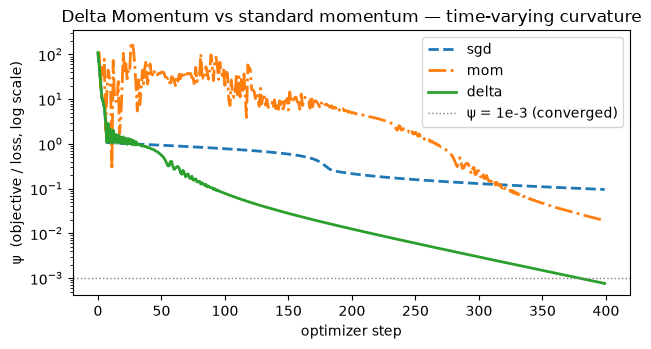

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# time-varying-curvature toy:  ψ(r,θ) = r² + k(r − θ + α·sin(ωr))²   (NL Eq. 53)
# ψ is the OBJECTIVE (loss) being minimized; (r,θ) are the variables (like weights).
k_, al, om = 5.0, 1.5, 3.0
grad = lambda p: np.array(
    [
        2 * p[0] + 2 * k_ * (p[0] - p[1] + al * np.sin(om * p[0])) * (1 + al * om * np.cos(om * p[0])),
        2 * k_ * (p[0] - p[1] + al * np.sin(om * p[0])) * (-1.0),
    ]
)
val = lambda p: p[0] ** 2 + k_ * (p[0] - p[1] + al * np.sin(om * p[0])) ** 2


def optimize(kind, steps=400, lr=0.01, beta=0.9):
    p = np.array([-3.5, 2.0])
    m = np.zeros(2)
    hist = []
    for _ in range(steps):
        g = grad(p)
        if kind == "sgd":
            p = p - lr * g  # no buffer
        elif kind == "mom":
            m = beta * m - lr * g
            p = p + m  # low-pass EMA
        elif kind == "delta":  # Eq.49, floored ≥0
            decay = max(0.0, beta - lr * (g @ g))
            m = decay * m - lr * g
            p = p + m
        hist.append(val(p))
    return np.array(hist)


reach = lambda h, th=1e-3: int(np.where(h < th)[0][0]) if (h < th).any() else None
curves = {}
for kind in ["sgd", "mom", "delta"]:
    h = optimize(kind)
    curves[kind] = h
    print(f"{kind:>5}: final ψ = {h[-1]:.2e}   steps to ψ<1e-3 : {reach(h)}")
print("\nSGD & standard momentum stall; Delta Momentum forgets stale gradients and reaches the floor.")

plt.figure(figsize=(6.5, 3.6))
for kind, style in [("sgd", "--"), ("mom", "-."), ("delta", "-")]:
    plt.semilogy(curves[kind], style, label=kind, lw=2)
plt.axhline(1e-3, color="gray", ls=":", lw=1, label="ψ = 1e-3 (converged)")
plt.xlabel("optimizer step")
plt.ylabel("ψ  (objective / loss, log scale)")
plt.title("Delta Momentum vs standard momentum — time-varying curvature")
plt.legend()
plt.tight_layout()
plt.show()

::: {.callout-note collapse="true"}
## Q: In the Delta-Momentum demo, why the guarded $(\alpha-\nabla\mathcal L^\top\nabla\mathcal L)$ decay?

That decay **is** the delta rule applied to the buffer (NL Eq. 49). DeltaNet's erase factor $(\mathbf I-\beta\mathbf k\mathbf k^\top)$ with the *gradient* as key ($\mathbf k=\nabla\mathcal L$) collapses to the scalar $(\alpha-\nabla\mathcal L^\top\nabla\mathcal L)$ — the buffer forgets in proportion to the current gradient's size. The literal factor goes **negative** when $\lVert\nabla\mathcal L\rVert^2>\alpha$, which flips the buffer's sign and makes it explode. So the code floors it at $0$ with `max(0, α − η‖g‖²)`: the same rule, made numerically safe.
:::

## 4. Adam and Muon, in the same picture

The associative-memory reading covers the *preconditioned* optimizers too (§4.2).

- **Preconditioning** $W_{t+1}=W_t-\eta\,P^{-1}\mathbf g$ (Eq. 38) is read as a memory that **maps gradients into a better coordinate system** $\hat{\mathbf g}$ (Eq. 39–40). **Adam** ([Kingma & Ba, 2014](https://arxiv.org/abs/1412.6980)) is the special case where $P$ is the optimal element-wise $\ell_2$ memory predicting the **variance of the gradient stream**. So Adam too is "just" an associative memory over gradients. Adam names its own parents in its first paragraph: it "is designed to combine the advantages of two recently popular methods: AdaGrad ([Duchi et al., 2011](https://www.jmlr.org/papers/v12/duchi11a.html)), which works well with sparse gradients, and RMSProp ([Tieleman & Hinton, 2012](http://www.cs.toronto.edu/~tijmen/csc321/slides/lecture_slides_lec6.pdf)), which works well in on-line and non-stationary settings" (§1): two existing memories over the gradient stream, combined, plus bias correction. [Shampoo](https://arxiv.org/abs/1802.09568) (Gupta, Koren & Singer, 2018) turns the same dial further, replacing the element-wise $P$ with a matrix-valued one.
- **Muon** (Eq. 42, 52) — introduced not in a paper but in a blog post ([Jordan et al., 2024](https://kellerjordan.github.io/posts/muon/)) — keeps the momentum buffer but passes its output through a **Newton–Schulz non-linearity** $\sigma=\mathrm{NS}_k$ that *orthogonalizes* it: $\mathrm{NS}_k$ iterates a cubic polynomial that drives the buffer's singular values toward $1$, which NL derives as one gradient step on an explicit orthogonality objective (Eqs. 43–44). In NL's grammar that is "a non-linearity on top of the memory's output" (Eq. 52): the standard way to raise a memory's representation power, here applied to the *gradient* memory.

  Muon is worth pausing on, because neither half is its own. The buffer is Polyak's, from 1964. The Newton–Schulz iteration is older still, out of numerical linear algebra, and it reached Muon by a route its authors record: Bernstein & Newhouse's [*Old Optimizer, New Norm*](https://arxiv.org/abs/2409.20325), whose Appendix A had recommended Newton–Schulz as a computational strategy for Shampoo. Muon is the composition of two borrowed parts — and its account of *why* orthogonalization helps is offered as a conjecture, not a result: the post speculates that it "effectively increases the scale of other 'rare directions' which have small magnitude in the update but are nevertheless important for learning."

In [ ]:
import torch

torch.manual_seed(0)


def newton_schulz(G, steps=5):  # whitens singular values toward 1
    a, b, c = 3.4445, -4.7750, 2.0315
    X = G / (G.norm() + 1e-7)
    for _ in range(steps):
        AX = X @ X.T
        X = a * X + b * (AX @ X) + c * (AX @ AX @ X)
    return X


m = torch.randn(8, 8)  # a momentum buffer (matrix-valued)
sb = torch.linalg.svdvals(m)
sa = torch.linalg.svdvals(newton_schulz(m))
print(f"momentum singular values  before NS : [{sb.min():.3f}, {sb.max():.3f}]")
print(f"momentum singular values  after  NS : [{sa.min():.3f}, {sa.max():.3f}]   (≈ orthogonal → all ~1)")
print("Muon = momentum memory + this non-linearity on its output (NL Eq. 52).")

momentum singular values  before NS : [0.781, 5.493]
momentum singular values  after  NS : [0.682, 1.109]   (≈ orthogonal → all ~1)
Muon = momentum memory + this non-linearity on its output (NL Eq. 52).


## 5. The payoff — the optimizer is a memory, so M4's toolkit applies to it

Put the five modules before this one side by side with this one, and they are the **same table**:

| | sequence memory (M1–M5) | optimizer (this module) |
|---|---|---|
| stream | tokens | gradients |
| key → value | $\mathbf k_t\to\mathbf v_t$ | layer input $\hat{\mathbf x}_t\to$ surprise $-\boldsymbol\delta_t$ |
| Hebbian write | linear attention (M3) | plain SGD |
| + forget gate | the global decay gate (M4 §4) | momentum decay $\alpha$ |
| delta write | DeltaNet (M4) | **DGD / Delta Momentum** |
| self-referential write | SRWM (M5) | backprop itself (§1.1) |
| deeper memory | — | **DMGD** (MLP buffer) |
| non-linear output | — | **Muon** (Newton–Schulz) |
| preconditioned | — | **Adam / AdaGrad / Shampoo** |

That collapses a distinction we never questioned. "Model" and "optimizer" looked like two different kinds of object: one stores knowledge, the other *adjusts* the thing that stores knowledge. They are the **same kind of object at different levels**: both associative memories compressing their own stream, tokens for the architecture and gradients for the optimizer. Both hit the same wall (correlated keys interfere, capacity is finite), and the same fixes work.

The consequence is practical: **every write rule you built in M1–M5 is now available to the optimizer**, because none of them were ever about sequences. DGD is the first instance cashed out: M4's read-before-write, applied to the weights, buying the same bounded updates under correlated inputs that it bought DeltaNet (§3). Delta Momentum is the second, the same rule with the gradient as the key (§3.1). The rest of the table is the rest of the toolkit — and the last three rows run the other way, the optimizer column carrying deep, non-linear and preconditioned memories with no counterpart on the sequence side of these foundations.

**Where this comes back.** Once the optimizer is a memory, the natural next question is what happens when the *sequence* memory is trained by one at inference time — that is [the Nested Learning track](../tracks/nested-learning/index.qmd). But nothing in the foundations depends on it: [M7](m7-three-dials.ipynb) closes the spine first.

## Code walkthrough — where this lives in real code

- [`optim/m3.py`](https://github.com/kmccleary3301/nested_learning/blob/main/src/nested_learning/optim/m3.py) in [kmccleary3301/nested_learning](https://github.com/kmccleary3301/nested_learning): a paper-faithful implementation of **Multi-scale Momentum Muon** ([NL](https://arxiv.org/abs/2512.24695) §7.2, Algorithm 1 — the paper abbreviates it *M3*, which has nothing to do with this course's M3). It is this module taken literally: *two* momentum buffers over the same gradient stream, updated at *different* frequencies, each passed through Newton–Schulz, then aggregated: a memory hierarchy living inside `Optimizer.step()`.
- [`optim/deep.py`](https://github.com/kmccleary3301/nested_learning/blob/main/src/nested_learning/optim/deep.py): `DeepMomentum` puts §4.4's momentum variants behind one `variant` switch: `preconditioned`, `l2_objective`, `nl_l2_precond`, `dmgd`, `muon`. Read it as a map of the design space rather than a faithful transcription: the `muon` variant, for instance, puts a `tanh` where the paper has Newton–Schulz.
- [`train_hope.py`](https://github.com/obekt/HOPE-nested-learning/blob/main/train_hope.py) in [obekt/HOPE-nested-learning](https://github.com/obekt/HOPE-nested-learning): the two levels in one file. `build_nested_optimizers` builds *one AdamW per tier*, each stepping on gradients averaged over its own update period, entirely *outside* the model; inside it, `SelfModifyingLayer` runs a per-token **delta-rule** write on its own memory.

The thing to notice in the code: the optimizer's `step()` and the memory's `update()` are the **same shape of operation** on different buffers — which is exactly the claim of this module.

## Exit check

Self-test before M7.

**1. In what precise sense is one SGD step an associative-memory write, and what are the key and the value?**
A linear layer's gradient factors as $\partial\mathcal L/\partial W=\boldsymbol\delta\,\hat{\mathbf x}^\top$ (NL Eq. 29, §1), an outer product. So $W\!\leftarrow\!W-\eta\,\boldsymbol\delta\hat{\mathbf x}^\top$ is the Hebbian write $\mathcal M\mathrel{+}=\mathbf v\mathbf k^\top$ with **key $=\hat{\mathbf x}$** (the layer's input) and **value $=-\boldsymbol\delta=-\partial\mathcal L/\partial\mathbf y$** (the negative output surprise). Training = the matrix accumulating these (input → surprise) outer products.

**2. Why is backprop-as-memory *not* just linear attention on gradients?**
Because the value it writes, $\mathbf u_t=-\partial\mathcal L/\partial\mathbf y_t$, is a **function of the current weights**: the memory generates its own write targets (the §1.1 demo: same input, different $W$ → different $\boldsymbol\delta$). Linear attention's value is an external, memory-independent input. That self-reference (Schmidhuber 1993) makes backprop a strictly richer memory and is what licenses a *delta-rule* optimizer in §4.5.

**3. In what sense is momentum a memory, and what is its capacity limit?**
The buffer $\mathbf m_{t+1}=\alpha\mathbf m_t-\eta\nabla\mathcal L$ is an associative memory that **compresses the gradient stream**: with $\alpha=1$ it is GD on $\langle\mathbf m\hat{\mathbf x},\boldsymbol\delta\rangle$, a value-less memory of past gradients (Eq. 34); $\alpha\neq1$ adds an $\ell_2$ forget term (§2). But the plain EMA is only a **low-pass filter**: at $\beta=0.9$ the last ~7 gradients carry 50% and the last ~44 carry 99% of the buffer (§2.1). Older gradients vanish geometrically, which is the optimizer-level cause of catastrophic forgetting on orthogonal tasks.

**4. What does DGD change relative to SGD, and how does it mirror M4?**
DGD swaps the dot-product inner objective for $\ell_2$-regression, giving $W_{t+1}=W_t(\mathbf I-\eta'\hat{\mathbf x}\hat{\mathbf x}^\top)-\eta'\nabla\mathcal L$ (Eq. 57, §3): it **erases what the current input already predicts, then writes the gradient**. That is *literally* DeltaNet's matrix form from M4, one level up (weights instead of a token memory). The benefit is the delta rule's: bounded, interference-resistant updates under correlated inputs — in the demo, SGD diverges at an aggressive lr while DGD stays bounded.

---

**Next → [M7 — The three dials](m7-three-dials.ipynb).** Six modules in, and every memory you have built has been a setting of one recurrence: what goes into the memory, what stays in it, and how the write is applied. It collapses the spine into that single equation, places every module you have read on it as a dial setting, and becomes the hub each track departs from.